Upload license_plate_detector.pt:


Saving license_plate_detector.pt to license_plate_detector (2).pt
Model and OCR loaded successfully

Cleaning up any existing database locks...
Cleanup warning: name 'DB_FILE' is not defined
Cleanup complete.
Smart Parking Database initialized with enhanced features

SMART PARKING SYSTEM INITIALIZED

FEATURES ENABLED:
  - Frame-by-frame video processing
  - License plate detection & OCR
  - Dynamic pricing engine
  - Membership management (Base/Gold/Premium)
  - Smart spot assignment
  - Interactive Folium maps (inline rendering)
  - Static matplotlib maps
  - Entry/Exit processing with payment
  - Loyalty points system
  - Violation tracking
  - Notification system
  - Comprehensive analytics
  - Vehicle history tracking
  - Database locking issues FIXED

SMART PARKING MANAGEMENT SYSTEM

OPERATIONS:
  [1] Vehicle Entry (Video)
  [2] Vehicle Entry (Image)
  [3] Vehicle Exit (Video)
  [4] Vehicle Exit (Manual - Enter Plate)
  [5] View Vehicle History
  [6] System Statistics
  [7] Check 

Saving car_in.mp4 to car_in.mp4

Video uploaded: car_in.mp4

VEHICLE ENTRY: VIDEO PROCESSING
VIDEO ANALYSIS
Total Frames: 497
FPS: 25
Duration: 19.88 seconds
Frame extraction interval: 10
Extracted 50 frames for analysis

Scanning 50 frames for license plate detection
Frame 1/50 - #0 at 0.00s

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Frame 50/50 - #490 at 19.60s

Detection successful: 4 plates found
Best: Frame #30 at 1.20s
Plate: CA455822
Confidence: 77.1% / OCR: 84.1%


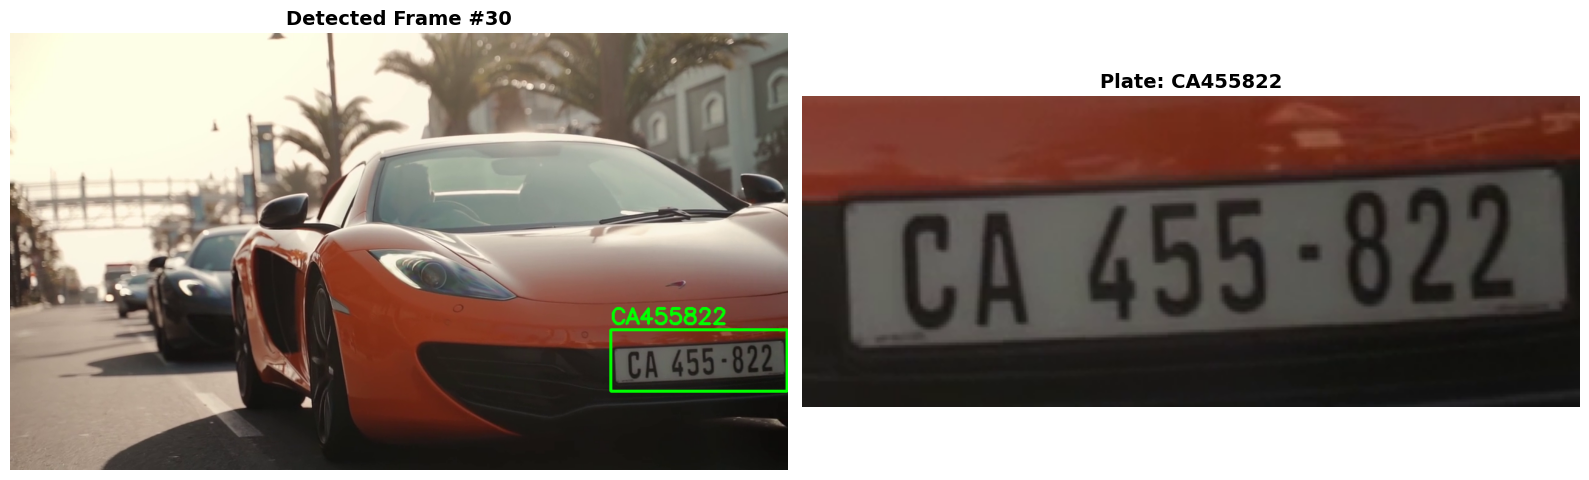


VEHICLE ENTRY PROCESSING

VEHICLE DATABASE
--------------------------------------------------------------------------------
Plate: CA455822
Owner: Alessandro Romano
Model: Lamborghini Aventador SVJ
Category: Luxury SUV
Registration: 2023-06-15

COMPLIANCE STATUS
Pollution Cert: Valid (Exp: 2026-06-30)
Insurance: Valid (Exp: 2026-06-30)

CONTACT
Phone: +91-9876543220
Email: alessandro@email.com

ACCOUNT
Lifetime Spending: Rs.8920.00
Loyalty Points: 892

MEMBERSHIP STATUS
--------------------------------------------------------------------------------
Tier: GOLD
Member Since: 2024-04-01
Valid Until: 2025-03-31
Total Visits: 34

DYNAMIC PRICING
--------------------------------------------------------------------------------
Base Rate (Luxury SUV): Rs.80/hour
Subtotal: Rs.80/hour
Discount (20%): -Rs.16.00/hour

Final Rate: Rs.64.00/hour
Estimated (2h): Rs.128.00

SMART SPOT ASSIGNMENT
--------------------------------------------------------------------------------
Assigned: F1A01
Floor: 1

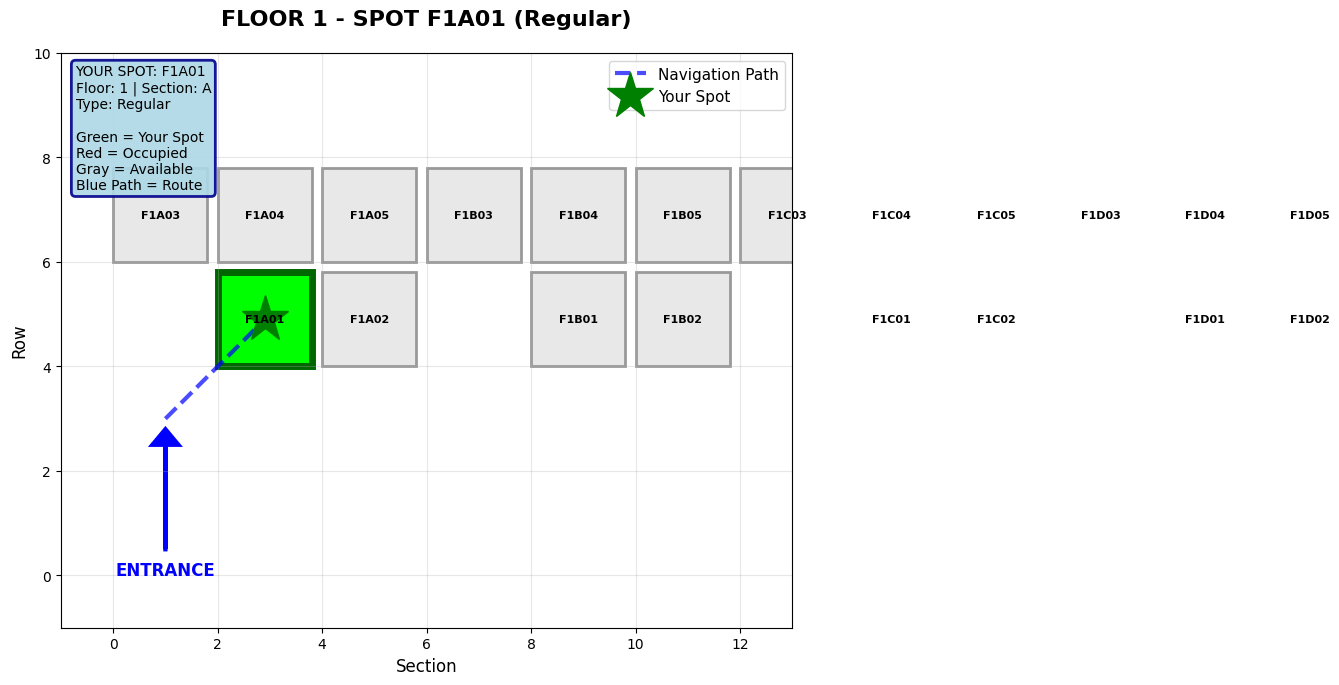


Interactive Folium Map (rendered inline):

Interactive map saved: parking_map_CA455822_1762719003.html


✓ Map displayed inline above

ENTRY COMPLETE
Time: 2025-11-09 20:10:02
Spot: F1A01 (Floor 1, Section A)
Estimated Cost: Rs.128.00

Follow blue path on map to your spot
Map also saved to: parking_map_CA455822_1762719003.html

SMART PARKING MANAGEMENT SYSTEM

OPERATIONS:
  [1] Vehicle Entry (Video)
  [2] Vehicle Entry (Image)
  [3] Vehicle Exit (Video)
  [4] Vehicle Exit (Manual - Enter Plate)
  [5] View Vehicle History
  [6] System Statistics
  [7] Check Violations
  [8] Exit System

PARKING HISTORY: 5
No parking history found

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
Total Visits: 0
Total Spent: Rs.0.00
Average Duration: N/A

SMART PARKING MANAGEMENT SYSTEM

OPERATIONS:
  [1] Vehicle Entry (Video)
  [2] Vehicle Entry (Image)
  [3] Vehicle Exit (Video)
  [4] Vehicle Exit (Manual - Enter Plate)
  [5] View Vehicle History
  [6] System Statistics
  [7]

Saving car_out.mp4 to car_out.mp4

Video uploaded: car_out.mp4

VEHICLE EXIT: VIDEO PROCESSING
VIDEO ANALYSIS
Total Frames: 497
FPS: 25
Duration: 19.88 seconds
Frame extraction interval: 10
Extracted 50 frames for analysis

Scanning 50 frames for license plate detection
Frame 50/50 - #490 at 19.60s

Detection successful: 4 plates found
Best: Frame #470 at 18.80s
Plate: C455822
Confidence: 76.8% / OCR: 73.8%


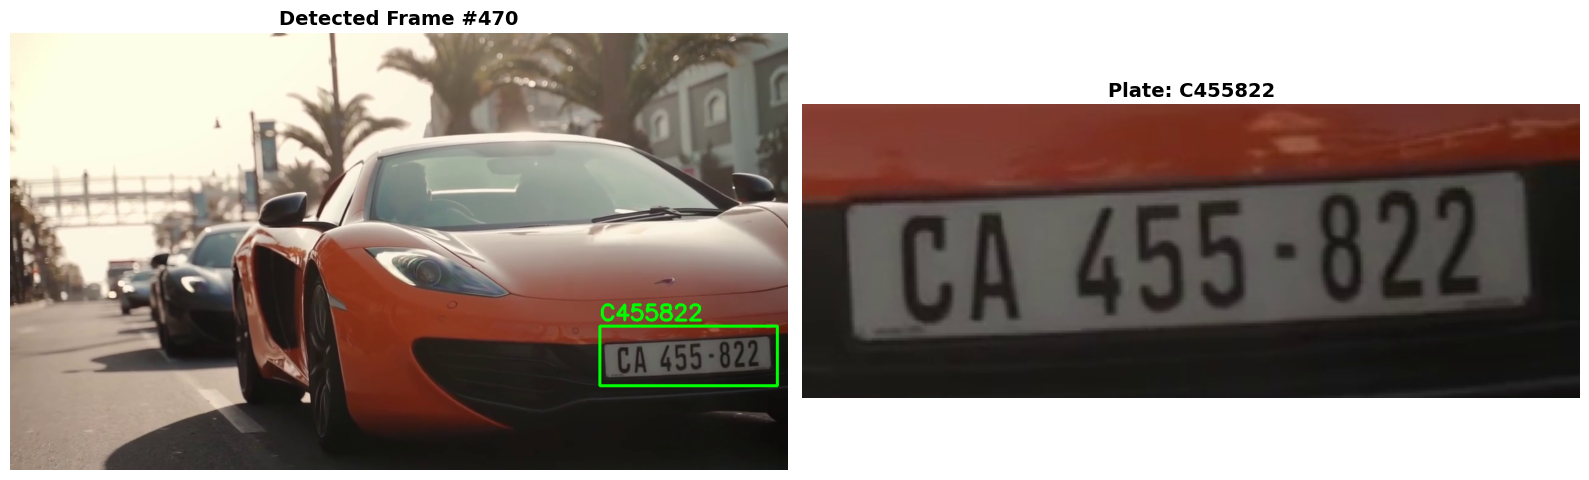


EXIT PROCESSING INITIATED
Vehicle C455822 not registered

SMART PARKING MANAGEMENT SYSTEM

OPERATIONS:
  [1] Vehicle Entry (Video)
  [2] Vehicle Entry (Image)
  [3] Vehicle Exit (Video)
  [4] Vehicle Exit (Manual - Enter Plate)
  [5] View Vehicle History
  [6] System Statistics
  [7] Check Violations
  [8] Exit System

Violations detected: 0


In [ ]:
!pip install ultralytics easyocr opencv-python-headless pillow numpy matplotlib folium

import cv2
import easyocr
from ultralytics import YOLO
import sqlite3
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import numpy as np
from datetime import datetime, timedelta
from google.colab import files
from IPython.display import display, clear_output, HTML, IFrame
import time
import random
import os
import folium
from folium import plugins
import base64
from io import BytesIO

print("Upload license_plate_detector.pt:")
uploaded = files.upload()

model = YOLO('license_plate_detector.pt')
reader = easyocr.Reader(['en'], gpu=True)
print("Model and OCR loaded successfully")


def cleanup_database_locks():
    """Remove existing database and WAL files to clear locks"""
    import os
    try:
        for ext in ['', '-shm', '-wal', '-journal']:
            file_path = DB_FILE + ext
            if os.path.exists(file_path):
                os.remove(file_path)
                print(f"Removed: {file_path}")
    except Exception as e:
        print(f"Cleanup warning: {e}")
print("\nCleaning up any existing database locks...")
cleanup_database_locks()
print("Cleanup complete.")

DB_TIMEOUT = 30.0
DB_FILE = 'smart_parking.db'


def get_db_connection():
    try:
        conn = sqlite3.connect(DB_FILE, timeout=DB_TIMEOUT, check_same_thread=False)
        conn.execute('PRAGMA journal_mode=WAL')
        return conn
    except sqlite3.OperationalError as e:
        print(f"Database connection error: {e}")
        print("Attempting to clean up lock files...")
        cleanup_database_locks()
        # Try again after cleanup
        conn = sqlite3.connect(DB_FILE, timeout=DB_TIMEOUT, check_same_thread=False)
        conn.execute('PRAGMA journal_mode=WAL')
        return conn

def setup_database():
    conn = get_db_connection()
    c = conn.cursor()

    c.execute('DROP TABLE IF EXISTS entry_log')
    c.execute('DROP TABLE IF EXISTS notifications')
    c.execute('DROP TABLE IF EXISTS violations')
    c.execute('DROP TABLE IF EXISTS memberships')
    c.execute('DROP TABLE IF EXISTS parking_spots')
    c.execute('DROP TABLE IF EXISTS vehicles')

    c.execute('''CREATE TABLE vehicles
                 (plate_number TEXT PRIMARY KEY,
                  owner_name TEXT,
                  car_model TEXT,
                  car_size TEXT,
                  registration_date TEXT,
                  pollution_cert_status TEXT,
                  pollution_cert_expiry TEXT,
                  insurance_status TEXT,
                  insurance_expiry TEXT,
                  phone TEXT,
                  email TEXT,
                  total_spent REAL DEFAULT 0,
                  loyalty_points INTEGER DEFAULT 0)''')

    c.execute('''CREATE TABLE memberships
                 (plate_number TEXT PRIMARY KEY,
                  membership_type TEXT,
                  join_date TEXT,
                  expiry_date TEXT,
                  total_visits INTEGER,
                  FOREIGN KEY(plate_number) REFERENCES vehicles(plate_number))''')

    c.execute('''CREATE TABLE parking_spots
                 (spot_id TEXT PRIMARY KEY,
                  spot_type TEXT,
                  floor INTEGER,
                  section TEXT,
                  x_coordinate REAL,
                  y_coordinate REAL,
                  latitude REAL,
                  longitude REAL,
                  is_occupied INTEGER,
                  occupied_by TEXT,
                  FOREIGN KEY(occupied_by) REFERENCES vehicles(plate_number))''')

    c.execute('''CREATE TABLE entry_log
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  plate_number TEXT,
                  entry_time TEXT,
                  exit_time TEXT,
                  spot_assigned TEXT,
                  estimated_cost REAL,
                  actual_cost REAL,
                  duration_hours REAL,
                  payment_status TEXT,
                  payment_method TEXT,
                  FOREIGN KEY(plate_number) REFERENCES vehicles(plate_number))''')

    c.execute('''CREATE TABLE notifications
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  plate_number TEXT,
                  notification_type TEXT,
                  message TEXT,
                  timestamp TEXT,
                  status TEXT,
                  FOREIGN KEY(plate_number) REFERENCES vehicles(plate_number))''')

    c.execute('''CREATE TABLE violations
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  plate_number TEXT,
                  violation_type TEXT,
                  violation_time TEXT,
                  fine_amount REAL,
                  paid INTEGER DEFAULT 0,
                  FOREIGN KEY(plate_number) REFERENCES vehicles(plate_number))''')

    sample_vehicles = [
        ('DL01AB1234', 'Rajesh Kumar', 'Honda City', 'Sedan', '2020-01-15',
         'Valid', '2025-12-31', 'Valid', '2026-01-31', '+91-9876543210', 'rajesh@email.com', 5420.0, 542),
        ('MH02CD5678', 'Priya Sharma', 'Maruti Swift', 'Hatchback', '2019-06-20',
         'Expired', '2024-11-30', 'Valid', '2025-03-31', '+91-9876543211', 'priya@email.com', 1230.0, 123),
        ('KA03EF9012', 'Amit Patel', 'Toyota Innova', 'SUV', '2021-03-10',
         'Valid', '2026-01-31', 'Valid', '2026-04-30', '+91-9876543212', 'amit@email.com', 3840.0, 384),
        ('TN04GH3456', 'Deepa Singh', 'Hyundai Creta', 'SUV', '2022-08-25',
         'Valid', '2025-08-31', 'Valid', '2025-09-30', '+91-9876543213', 'deepa@email.com', 7260.0, 726),
        ('UP05IJ7890', 'Vikram Gupta', 'Tata Nexon', 'Compact SUV', '2023-02-14',
         'Valid', '2026-02-28', 'Valid', '2027-02-28', '+91-9876543214', 'vikram@email.com', 2890.0, 289),
        ('GJ06KL2345', 'Sneha Desai', 'BMW X5', 'Luxury SUV', '2020-09-12',
         'Valid', '2025-09-30', 'Valid', '2025-10-31', '+91-9876543215', 'sneha@email.com', 12450.0, 1245),
        ('CA455822', 'Alessandro Romano', 'Lamborghini Aventador SVJ', 'Luxury SUV', '2023-06-15',
         'Valid', '2026-06-30', 'Valid', '2026-06-30', '+91-9876543220', 'alessandro@email.com', 8920.0, 892),
    ]

    sample_memberships = [
        ('DL01AB1234', 'Premium', '2024-01-01', '2025-12-31', 45),
        ('MH02CD5678', 'Base', '2024-06-01', '2025-05-31', 12),
        ('KA03EF9012', 'Gold', '2024-03-01', '2025-02-28', 28),
        ('TN04GH3456', 'Premium', '2024-02-01', '2025-01-31', 67),
        ('GJ06KL2345', 'Premium', '2024-01-15', '2025-01-14', 89),
        ('CA455822', 'Gold', '2024-04-01', '2025-03-31', 34),
    ]

    base_lat = 28.6139
    base_lon = 77.2090

    parking_spots = []
    spot_types = ['Regular', 'Compact', 'Large', 'EV', 'Disabled']
    sections = ['A', 'B', 'C', 'D']

    for floor in range(1, 4):
        for section in sections:
            for spot_num in range(1, 6):
                spot_id = f"F{floor}{section}{spot_num:02d}"
                spot_type = random.choice(spot_types)
                x = (sections.index(section) * 3) + (spot_num % 3)
                y = floor * 2 + (spot_num // 3)

                lat = base_lat + (y * 0.00005) + (floor * 0.0001)
                lon = base_lon + (x * 0.00005)

                parking_spots.append((spot_id, spot_type, floor, section, x, y, lat, lon, 0, None))

    c.executemany('INSERT INTO vehicles VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)', sample_vehicles)
    c.executemany('INSERT INTO memberships VALUES (?,?,?,?,?)', sample_memberships)
    c.executemany('INSERT INTO parking_spots VALUES (?,?,?,?,?,?,?,?,?,?)', parking_spots)

    conn.commit()
    conn.close()

    print("Smart Parking Database initialized with enhanced features")

def enhance_plate_image(plate_img):
    enhanced_images = []

    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    enhanced_images.append(("Original", plate_img))
    enhanced_images.append(("Grayscale", gray))

    equalized = cv2.equalizeHist(gray)
    enhanced_images.append(("Equalized", equalized))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(gray)
    enhanced_images.append(("CLAHE", clahe_img))

    bilateral = cv2.bilateralFilter(gray, 11, 17, 17)
    enhanced_images.append(("Bilateral", bilateral))

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    enhanced_images.append(("Threshold", thresh))

    adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)
    enhanced_images.append(("Adaptive", adaptive))

    return enhanced_images

def extract_text_from_plate(plate_img):
    enhanced_images = enhance_plate_image(plate_img)
    all_results = []

    for name, img in enhanced_images:
        try:
            ocr_output = reader.readtext(img, detail=1)
            for detection in ocr_output:
                text = detection[1]
                confidence = detection[2]
                cleaned = re.sub(r'[^A-Z0-9]', '', text.upper())

                if len(cleaned) >= 6 and len(cleaned) <= 13:
                    all_results.append({
                        'text': cleaned,
                        'confidence': confidence,
                        'method': name
                    })
        except:
            continue

    if all_results:
        all_results.sort(key=lambda x: (x['confidence'], len(x['text'])), reverse=True)
        return all_results[0]

    return None

def extract_frames_from_video(video_path, frame_interval=15):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error opening video file")
        return []

    frames = []
    frame_count = 0
    extracted_count = 0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    print(f"VIDEO ANALYSIS")
    print(f"Total Frames: {total_frames}")
    print(f"FPS: {fps}")
    print(f"Duration: {total_frames/fps:.2f} seconds")
    print(f"Frame extraction interval: {frame_interval}")

    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % frame_interval == 0:
            frames.append({
                'frame': frame,
                'frame_number': frame_count,
                'timestamp': frame_count / fps
            })
            extracted_count += 1

        frame_count += 1

    cap.release()

    print(f"Extracted {extracted_count} frames for analysis")

    return frames

def detect_plate_from_image(frame):
    results = model(frame, conf=0.25, verbose=False)

    best_detection = None
    highest_confidence = 0

    for result in results:
        boxes = result.boxes

        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                confidence = float(box.conf[0].cpu().numpy())

                if confidence > 0.3 and confidence > highest_confidence:
                    padding = 10
                    h, w = frame.shape[:2]
                    y1_crop = max(0, y1 - padding)
                    y2_crop = min(h, y2 + padding)
                    x1_crop = max(0, x1 - padding)
                    x2_crop = min(w, x2 + padding)

                    plate_img = frame[y1_crop:y2_crop, x1_crop:x2_crop]

                    if plate_img.size == 0:
                        continue

                    if plate_img.shape[0] < 50 or plate_img.shape[1] < 150:
                        scale = max(50 / plate_img.shape[0], 150 / plate_img.shape[1])
                        new_width = int(plate_img.shape[1] * scale)
                        new_height = int(plate_img.shape[0] * scale)
                        plate_img = cv2.resize(plate_img, (new_width, new_height),
                                              interpolation=cv2.INTER_CUBIC)

                    ocr_result = extract_text_from_plate(plate_img)

                    if ocr_result and ocr_result['confidence'] > 0.5:
                        best_detection = {
                            'plate_number': ocr_result['text'],
                            'detection_confidence': confidence,
                            'ocr_confidence': ocr_result['confidence'],
                            'bbox': (x1, y1, x2, y2),
                            'plate_image': plate_img,
                            'method': ocr_result['method']
                        }
                        highest_confidence = confidence

    return best_detection

def scan_video_for_plates(video_path, mode='entry'):
    print("\n" + "="*80)
    if mode == 'entry':
        print("VEHICLE ENTRY: VIDEO PROCESSING")
    else:
        print("VEHICLE EXIT: VIDEO PROCESSING")
    print("="*80)

    frames = extract_frames_from_video(video_path, frame_interval=10)

    if not frames:
        print("No frames extracted")
        return None

    print(f"\nScanning {len(frames)} frames for license plate detection")

    detections = []

    for i, frame_data in enumerate(frames):
        frame = frame_data['frame']
        frame_num = frame_data['frame_number']
        timestamp = frame_data['timestamp']

        print(f"\rFrame {i+1}/{len(frames)} - #{frame_num} at {timestamp:.2f}s", end='')

        detection = detect_plate_from_image(frame)

        if detection:
            detection['frame_number'] = frame_num
            detection['timestamp'] = timestamp
            detection['frame'] = frame
            detections.append(detection)

    print("\n")

    if not detections:
        print("No license plates detected")
        return None

    best = max(detections, key=lambda x: x['detection_confidence'] * x['ocr_confidence'])

    print(f"Detection successful: {len(detections)} plates found")
    print(f"Best: Frame #{best['frame_number']} at {best['timestamp']:.2f}s")
    print(f"Plate: {best['plate_number']}")
    print(f"Confidence: {best['detection_confidence']:.1%} / OCR: {best['ocr_confidence']:.1%}")

    frame_with_box = best['frame'].copy()
    x1, y1, x2, y2 = best['bbox']
    cv2.rectangle(frame_with_box, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(frame_with_box, best['plate_number'], (x1, y1-10),
               cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    frame_rgb = cv2.cvtColor(frame_with_box, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(frame_rgb)
    axes[0].set_title(f"Detected Frame #{best['frame_number']}", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    plate_rgb = cv2.cvtColor(best['plate_image'], cv2.COLOR_BGR2RGB)
    axes[1].imshow(plate_rgb)
    axes[1].set_title(f"Plate: {best['plate_number']}", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return best

def calculate_parking_cost(vehicle_data, membership_data, duration_hours=None):
    base_rates = {
        'Hatchback': 30,
        'Sedan': 40,
        'Compact SUV': 50,
        'SUV': 60,
        'Luxury SUV': 80,
        'Default': 40
    }

    car_size = vehicle_data.get('car_size', 'Default')
    base_rate = base_rates.get(car_size, base_rates['Default'])

    membership_discounts = {
        'Premium': 0.30,
        'Gold': 0.20,
        'Base': 0.10,
        'None': 0.00
    }

    membership_type = membership_data.get('membership_type', 'None') if membership_data else 'None'
    discount = membership_discounts.get(membership_type, 0.0)

    pollution_penalty = 0
    if vehicle_data.get('pollution_cert_status') == 'Expired':
        pollution_penalty = 20

    insurance_penalty = 0
    if vehicle_data.get('insurance_status') == 'Expired':
        insurance_penalty = 15

    rate_before_discount = base_rate + pollution_penalty + insurance_penalty
    discount_amount = rate_before_discount * discount
    final_rate = rate_before_discount - discount_amount

    if duration_hours is None:
        estimated_hours = 2
    else:
        estimated_hours = duration_hours

    estimated_cost = final_rate * estimated_hours

    return {
        'base_rate': base_rate,
        'pollution_penalty': pollution_penalty,
        'insurance_penalty': insurance_penalty,
        'rate_before_discount': rate_before_discount,
        'membership_discount': discount_amount,
        'final_hourly_rate': final_rate,
        'estimated_hours': estimated_hours,
        'estimated_cost': estimated_cost,
        'membership_type': membership_type,
        'discount_percentage': int(discount * 100)
    }

def assign_parking_spot(plate_number, car_size):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT * FROM parking_spots WHERE is_occupied=0')
        available_spots = c.fetchall()

        if not available_spots:
            return None

        preferred_types = {
            'Hatchback': ['Compact', 'Regular'],
            'Sedan': ['Regular', 'Compact'],
            'Compact SUV': ['Regular', 'Large'],
            'SUV': ['Large', 'Regular'],
            'Luxury SUV': ['Large', 'Regular']
        }

        preferred = preferred_types.get(car_size, ['Regular'])

        best_spot = None
        for spot in available_spots:
            spot_type = spot[1]
            if spot_type in preferred:
                best_spot = spot
                break

        if not best_spot:
            best_spot = available_spots[0]

        spot_id = best_spot[0]
        c.execute('UPDATE parking_spots SET is_occupied=1, occupied_by=? WHERE spot_id=?',
                  (plate_number, spot_id))
        conn.commit()

        return {
            'spot_id': spot_id,
            'floor': best_spot[2],
            'section': best_spot[3],
            'spot_type': best_spot[1],
            'x': best_spot[4],
            'y': best_spot[5],
            'latitude': best_spot[6],
            'longitude': best_spot[7]
        }
    finally:
        conn.close()

def get_vehicle_info(plate_number):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT * FROM vehicles WHERE plate_number=?', (plate_number,))
        result = c.fetchone()

        if result:
            return {
                'plate_number': result[0],
                'owner_name': result[1],
                'car_model': result[2],
                'car_size': result[3],
                'registration_date': result[4],
                'pollution_cert_status': result[5],
                'pollution_cert_expiry': result[6],
                'insurance_status': result[7],
                'insurance_expiry': result[8],
                'phone': result[9],
                'email': result[10],
                'total_spent': result[11],
                'loyalty_points': result[12]
            }
        return None
    finally:
        conn.close()

def get_membership_info(plate_number):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT * FROM memberships WHERE plate_number=?', (plate_number,))
        result = c.fetchone()

        if result:
            return {
                'plate_number': result[0],
                'membership_type': result[1],
                'join_date': result[2],
                'expiry_date': result[3],
                'total_visits': result[4]
            }
        return None
    finally:
        conn.close()

def log_entry(plate_number, spot_id, estimated_cost):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        entry_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        c.execute('INSERT INTO entry_log (plate_number, entry_time, spot_assigned, estimated_cost, payment_status) VALUES (?,?,?,?,?)',
                  (plate_number, entry_time, spot_id, estimated_cost, 'Pending'))

        c.execute('UPDATE memberships SET total_visits = total_visits + 1 WHERE plate_number=?', (plate_number,))

        c.execute('INSERT INTO notifications (plate_number, notification_type, message, timestamp, status) VALUES (?,?,?,?,?)',
                  (plate_number, 'Entry', f'Vehicle entered and assigned to spot {spot_id}', entry_time, 'Sent'))

        conn.commit()
        return entry_time
    finally:
        conn.close()

def create_interactive_parking_map(assigned_spot, vehicle_plate):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        floor = assigned_spot['floor']

        c.execute('SELECT * FROM parking_spots WHERE floor=?', (floor,))
        spots = c.fetchall()

        center_lat = assigned_spot['latitude']
        center_lon = assigned_spot['longitude']

        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=19,
            tiles='OpenStreetMap'
        )

        entrance_lat = center_lat - 0.0003
        entrance_lon = center_lon - 0.0003

        folium.Marker(
            [entrance_lat, entrance_lon],
            popup='PARKING ENTRANCE',
            tooltip='Start Here',
            icon=folium.Icon(color='blue', icon='road', prefix='fa')
        ).add_to(m)

        for spot in spots:
            spot_id, spot_type, floor_num, section, x, y, lat, lon, is_occupied, occupied_by = spot

            if spot_id == assigned_spot['spot_id']:
                color = 'green'
                icon_name = 'star'
                popup_text = f"YOUR SPOT: {spot_id}<br>Type: {spot_type}<br>Vehicle: {vehicle_plate}"
                tooltip_text = f'YOUR ASSIGNED SPOT {spot_id}'
            elif is_occupied:
                color = 'red'
                icon_name = 'car'
                popup_text = f"Occupied: {spot_id}<br>Type: {spot_type}"
                tooltip_text = f'Occupied {spot_id}'
            else:
                color = 'gray'
                icon_name = 'square'
                popup_text = f"Available: {spot_id}<br>Type: {spot_type}"
                tooltip_text = f'Available {spot_id}'

            folium.Marker(
                [lat, lon],
                popup=folium.Popup(popup_text, max_width=200),
                tooltip=tooltip_text,
                icon=folium.Icon(color=color, icon=icon_name, prefix='fa')
            ).add_to(m)

        route_coords = [
            [entrance_lat, entrance_lon],
            [entrance_lat + 0.00010, entrance_lon + 0.00010],
            [assigned_spot['latitude'] - 0.00005, assigned_spot['longitude'] - 0.00005],
            [assigned_spot['latitude'], assigned_spot['longitude']]
        ]

        folium.PolyLine(
            route_coords,
            color='blue',
            weight=5,
            opacity=0.8,
            popup='Navigation Route',
            tooltip='Follow this path'
        ).add_to(m)

        plugins.AntPath(
            route_coords,
            color='blue',
            weight=3,
            opacity=0.6,
            dash_array=[20, 30]
        ).add_to(m)

        folium.Circle(
            [assigned_spot['latitude'], assigned_spot['longitude']],
            radius=3,
            color='green',
            fill=True,
            fillColor='green',
            fillOpacity=0.6,
            popup='Destination'
        ).add_to(m)

        legend_html = f'''
        <div style="position: fixed;
                    bottom: 50px; right: 50px; width: 250px; height: 200px;
                    background-color: white; border:2px solid grey; z-index:9999;
                    font-size:14px; padding: 10px">
        <h4 style="margin-top:0">Parking Map Legend</h4>
        <p><i class="fa fa-star" style="color:green"></i> Your Spot: {assigned_spot['spot_id']}</p>
        <p><i class="fa fa-car" style="color:red"></i> Occupied Spots</p>
        <p><i class="fa fa-square" style="color:gray"></i> Available Spots</p>
        <p><i class="fa fa-road" style="color:blue"></i> Entrance</p>
        <p style="color:blue; font-weight:bold">Follow Blue Path</p>
        </div>
        '''
        m.get_root().html.add_child(folium.Element(legend_html))

        map_file = f'parking_map_{vehicle_plate}_{int(time.time())}.html'
        m.save(map_file)

        print(f"\nInteractive map saved: {map_file}")

        try:
            map_html = m._repr_html_()
            display(HTML(map_html))
            print("✓ Map displayed inline above")
        except:
            try:
                display(IFrame(src=map_file, width=900, height=600))
                print("✓ Map displayed in IFrame above")
            except:
                print("\n" + "="*80)
                print("MAP DOWNLOAD")
                print("="*80)
                print(f"Download the map file: {map_file}")
                print("Then open it in your browser to view the interactive map")
                print("="*80)

                from IPython.display import FileLink
                display(FileLink(map_file))

        return m, map_file
    finally:
        conn.close()

def generate_static_map(assigned_spot):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        floor = assigned_spot['floor']

        c.execute('SELECT * FROM parking_spots WHERE floor=?', (floor,))
        spots = c.fetchall()

        fig, ax = plt.subplots(figsize=(16, 12))

        for spot in spots:
            spot_id, spot_type, floor_num, section, x, y, lat, lon, is_occupied, occupied_by = spot

            if spot_id == assigned_spot['spot_id']:
                color = '#00FF00'
                edge_color = '#006600'
                linewidth = 5
            elif is_occupied:
                color = '#FF6B6B'
                edge_color = '#CC0000'
                linewidth = 2
            else:
                color = '#E8E8E8'
                edge_color = '#999999'
                linewidth = 2

            rect = patches.Rectangle((x*2, y*2), 1.8, 1.8,
                                     linewidth=linewidth,
                                     edgecolor=edge_color,
                                     facecolor=color)
            ax.add_patch(rect)

            ax.text(x*2 + 0.9, y*2 + 0.9, spot_id,
                   ha='center', va='center',
                   fontsize=8, fontweight='bold')

        ax.arrow(1, 0.5, 0, 2, head_width=0.5, head_length=0.3,
                fc='blue', ec='blue', linewidth=3)
        ax.text(1, 0, 'ENTRANCE', ha='center', fontsize=12, fontweight='bold', color='blue')

        entrance_x, entrance_y = 1, 3
        spot_x, spot_y = assigned_spot['x']*2 + 0.9, assigned_spot['y']*2 + 0.9

        ax.plot([entrance_x, spot_x], [entrance_y, spot_y],
               'b--', linewidth=3, label='Navigation Path', alpha=0.7)

        ax.plot(spot_x, spot_y, 'g*', markersize=35, label='Your Spot')

        ax.set_xlim(-1, 13)
        ax.set_ylim(-1, 10)
        ax.set_aspect('equal')
        ax.set_title(f'FLOOR {floor} - SPOT {assigned_spot["spot_id"]} ({assigned_spot["spot_type"]})',
                    fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='upper right', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Section', fontsize=12)
        ax.set_ylabel('Row', fontsize=12)

        legend_text = (
            f"YOUR SPOT: {assigned_spot['spot_id']}\n"
            f"Floor: {assigned_spot['floor']} | Section: {assigned_spot['section']}\n"
            f"Type: {assigned_spot['spot_type']}\n\n"
            f"Green = Your Spot\n"
            f"Red = Occupied\n"
            f"Gray = Available\n"
            f"Blue Path = Route"
        )
        ax.text(0.02, 0.98, legend_text, transform=ax.transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9, edgecolor='darkblue', linewidth=2))

        plt.tight_layout()
        return fig
    finally:
        conn.close()

def send_notification(plate_number, notification_type, message):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        c.execute('INSERT INTO notifications (plate_number, notification_type, message, timestamp, status) VALUES (?,?,?,?,?)',
                  (plate_number, notification_type, message, timestamp, 'Sent'))

        conn.commit()
    finally:
        conn.close()

def check_active_parking(plate_number):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT * FROM entry_log WHERE plate_number=? AND exit_time IS NULL ORDER BY id DESC LIMIT 1',
                  (plate_number,))
        result = c.fetchone()

        if result:
            return {
                'id': result[0],
                'plate_number': result[1],
                'entry_time': result[2],
                'spot_assigned': result[4],
                'estimated_cost': result[5]
            }
        return None
    finally:
        conn.close()

def process_exit(plate_number, exit_detection):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        active_parking = check_active_parking(plate_number)

        if not active_parking:
            print(f"\nNo active parking session found for {plate_number}")
            return None

        vehicle_data = get_vehicle_info(plate_number)
        membership_data = get_membership_info(plate_number)

        entry_time = datetime.strptime(active_parking['entry_time'], '%Y-%m-%d %H:%M:%S')
        exit_time = datetime.now()
        duration = exit_time - entry_time
        duration_hours = duration.total_seconds() / 3600

        if duration_hours < 0.1:
            duration_hours = 0.1

        pricing = calculate_parking_cost(vehicle_data, membership_data, duration_hours)
        actual_cost = pricing['estimated_cost']

        loyalty_points = int(actual_cost / 10)

        exit_time_str = exit_time.strftime('%Y-%m-%d %H:%M:%S')

        c.execute('''UPDATE entry_log
                     SET exit_time=?, duration_hours=?, actual_cost=?, payment_status=?
                     WHERE id=?''',
                  (exit_time_str, duration_hours, actual_cost, 'Paid', active_parking['id']))

        c.execute('UPDATE parking_spots SET is_occupied=0, occupied_by=NULL WHERE spot_id=?',
                  (active_parking['spot_assigned'],))

        c.execute('UPDATE vehicles SET total_spent=total_spent+?, loyalty_points=loyalty_points+? WHERE plate_number=?',
                  (actual_cost, loyalty_points, plate_number))

        conn.commit()

        send_notification(plate_number, 'Exit', f'Vehicle exited. Duration: {duration_hours:.2f}h. Cost: Rs.{actual_cost:.2f}')

        return {
            'entry_time': entry_time,
            'exit_time': exit_time,
            'duration': duration,
            'duration_hours': duration_hours,
            'spot': active_parking['spot_assigned'],
            'estimated_cost': active_parking['estimated_cost'],
            'actual_cost': actual_cost,
            'pricing': pricing,
            'loyalty_points_earned': loyalty_points
        }
    finally:
        conn.close()

def display_exit_summary(plate_number, exit_data, vehicle_data, membership_data):
    print("\n" + "="*80)
    print("VEHICLE EXIT PROCESSING")
    print("="*80)

    print("\nVEHICLE INFORMATION")
    print("-" * 80)
    print(f"Plate: {plate_number}")
    print(f"Owner: {vehicle_data['owner_name']}")
    print(f"Model: {vehicle_data['car_model']}")

    if membership_data:
        print(f"Membership: {membership_data['membership_type']}")

    print("\nPARKING SESSION DETAILS")
    print("-" * 80)
    print(f"Spot Used: {exit_data['spot']}")
    print(f"Entry Time: {exit_data['entry_time'].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Exit Time: {exit_data['exit_time'].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Duration: {int(exit_data['duration_hours'])}h {int((exit_data['duration_hours'] % 1) * 60)}m")

    print("\nPAYMENT CALCULATION")
    print("-" * 80)
    print(f"Hourly Rate: Rs.{exit_data['pricing']['final_hourly_rate']:.2f}/hour")
    print(f"Duration: {exit_data['duration_hours']:.2f} hours")
    print(f"Total Amount: Rs.{exit_data['actual_cost']:.2f}")

    if exit_data['pricing']['membership_discount'] > 0:
        print(f"Membership Discount Applied: Rs.{exit_data['pricing']['membership_discount']:.2f}/hour")

    print(f"\nPayment Status: PAID")
    print(f"Loyalty Points Earned: {exit_data['loyalty_points_earned']}")

    print("\nUPDATED ACCOUNT")
    print("-" * 80)
    print(f"Total Lifetime Spending: Rs.{vehicle_data['total_spent'] + exit_data['actual_cost']:.2f}")
    print(f"Total Loyalty Points: {vehicle_data['loyalty_points'] + exit_data['loyalty_points_earned']}")

    print("\n" + "="*80)
    print("EXIT PROCESSED SUCCESSFULLY")
    print("Parking spot released and available for new vehicles")
    print("="*80)

def process_vehicle_entry(plate_number):
    print("\n" + "="*80)
    print("VEHICLE ENTRY PROCESSING")
    print("="*80)

    vehicle_data = get_vehicle_info(plate_number)

    if not vehicle_data:
        print(f"Vehicle {plate_number} not registered")
        print("Please complete registration at office")
        return

    active = check_active_parking(plate_number)
    if active:
        print(f"\nVehicle {plate_number} already has active parking session")
        print(f"Currently parked at: {active['spot_assigned']}")
        print(f"Entry time: {active['entry_time']}")
        return

    membership_data = get_membership_info(plate_number)

    print("\nVEHICLE DATABASE")
    print("-" * 80)
    print(f"Plate: {vehicle_data['plate_number']}")
    print(f"Owner: {vehicle_data['owner_name']}")
    print(f"Model: {vehicle_data['car_model']}")
    print(f"Category: {vehicle_data['car_size']}")
    print(f"Registration: {vehicle_data['registration_date']}")
    print(f"\nCOMPLIANCE STATUS")
    print(f"Pollution Cert: {vehicle_data['pollution_cert_status']} (Exp: {vehicle_data['pollution_cert_expiry']})")
    print(f"Insurance: {vehicle_data['insurance_status']} (Exp: {vehicle_data['insurance_expiry']})")
    print(f"\nCONTACT")
    print(f"Phone: {vehicle_data['phone']}")
    print(f"Email: {vehicle_data['email']}")
    print(f"\nACCOUNT")
    print(f"Lifetime Spending: Rs.{vehicle_data['total_spent']:.2f}")
    print(f"Loyalty Points: {vehicle_data['loyalty_points']}")

    print("\nMEMBERSHIP STATUS")
    print("-" * 80)
    if membership_data:
        print(f"Tier: {membership_data['membership_type'].upper()}")
        print(f"Member Since: {membership_data['join_date']}")
        print(f"Valid Until: {membership_data['expiry_date']}")
        print(f"Total Visits: {membership_data['total_visits']}")

        expiry_date = datetime.strptime(membership_data['expiry_date'], '%Y-%m-%d')
        days_left = (expiry_date - datetime.now()).days
        if days_left < 30:
            print(f"WARNING: Membership expires in {days_left} days")
    else:
        print("No Active Membership")
        print("Available: Base (10%), Gold (20%), Premium (30%)")

    pricing = calculate_parking_cost(vehicle_data, membership_data)

    print("\nDYNAMIC PRICING")
    print("-" * 80)
    print(f"Base Rate ({vehicle_data['car_size']}): Rs.{pricing['base_rate']}/hour")

    if pricing['pollution_penalty'] > 0:
        print(f"Pollution Penalty: +Rs.{pricing['pollution_penalty']}/hour")

    if pricing['insurance_penalty'] > 0:
        print(f"Insurance Penalty: +Rs.{pricing['insurance_penalty']}/hour")

    print(f"Subtotal: Rs.{pricing['rate_before_discount']}/hour")

    if pricing['membership_discount'] > 0:
        print(f"Discount ({pricing['discount_percentage']}%): -Rs.{pricing['membership_discount']:.2f}/hour")

    print(f"\nFinal Rate: Rs.{pricing['final_hourly_rate']:.2f}/hour")
    print(f"Estimated ({pricing['estimated_hours']}h): Rs.{pricing['estimated_cost']:.2f}")

    print("\nSMART SPOT ASSIGNMENT")
    print("-" * 80)

    spot = assign_parking_spot(plate_number, vehicle_data['car_size'])

    if not spot:
        print("All spots occupied. Please wait.")
        return

    print(f"Assigned: {spot['spot_id']}")
    print(f"Floor: {spot['floor']} | Section: {spot['section']}")
    print(f"Type: {spot['spot_type']}")
    print(f"Optimal match for {vehicle_data['car_size']}")

    entry_time = log_entry(plate_number, spot['spot_id'], pricing['estimated_cost'])

    print("\nGENERATING NAVIGATION")
    print("-" * 80)

    print("\nStatic Map:")
    static_fig = generate_static_map(spot)
    plt.show()

    print("\nInteractive Folium Map (rendered inline):")
    interactive_map, map_file = create_interactive_parking_map(spot, plate_number)

    print("\n" + "="*80)
    print("ENTRY COMPLETE")
    print("="*80)
    print(f"Time: {entry_time}")
    print(f"Spot: {spot['spot_id']} (Floor {spot['floor']}, Section {spot['section']})")
    print(f"Estimated Cost: Rs.{pricing['estimated_cost']:.2f}")
    print("\nFollow blue path on map to your spot")
    print(f"Map also saved to: {map_file}")
    print("="*80)

def process_vehicle_exit_flow(plate_number):
    print("\n" + "="*80)
    print("EXIT PROCESSING INITIATED")
    print("="*80)

    vehicle_data = get_vehicle_info(plate_number)

    if not vehicle_data:
        print(f"Vehicle {plate_number} not registered")
        return

    active = check_active_parking(plate_number)

    if not active:
        print(f"No active parking session for {plate_number}")
        print("Vehicle may have already exited or never entered")
        return

    membership_data = get_membership_info(plate_number)

    exit_data = process_exit(plate_number, None)

    if exit_data:
        display_exit_summary(plate_number, exit_data, vehicle_data, membership_data)

def display_system_statistics():
    print("\n\n" + "="*80)
    print("SYSTEM ANALYTICS DASHBOARD")
    print("="*80)

    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT COUNT(*) FROM parking_spots WHERE is_occupied=1')
        occupied = c.fetchone()[0]

        c.execute('SELECT COUNT(*) FROM parking_spots')
        total = c.fetchone()[0]

        available = total - occupied
        occupancy_rate = (occupied/total)*100 if total > 0 else 0

        c.execute('SELECT COUNT(*) FROM entry_log')
        total_entries = c.fetchone()[0]

        c.execute('SELECT COUNT(*) FROM entry_log WHERE exit_time IS NULL')
        active_sessions = c.fetchone()[0]

        c.execute('SELECT COUNT(*) FROM memberships')
        total_members = c.fetchone()[0]

        c.execute('SELECT COUNT(*) FROM vehicles')
        registered_vehicles = c.fetchone()[0]

        c.execute('SELECT membership_type, COUNT(*) FROM memberships GROUP BY membership_type')
        membership_breakdown = c.fetchall()

        c.execute('SELECT floor, COUNT(*) FROM parking_spots WHERE is_occupied=1 GROUP BY floor')
        floor_occupancy = c.fetchall()

        c.execute('SELECT SUM(actual_cost) FROM entry_log WHERE actual_cost IS NOT NULL')
        total_revenue = c.fetchone()[0] or 0

        c.execute('SELECT AVG(duration_hours) FROM entry_log WHERE duration_hours IS NOT NULL')
        avg_duration = c.fetchone()[0] or 0

        c.execute('SELECT COUNT(*) FROM violations WHERE paid=0')
        unpaid_violations = c.fetchone()[0]

        c.execute('SELECT COUNT(*) FROM notifications')
        total_notifications = c.fetchone()[0]

        print("\nPARKING CAPACITY")
        print("-" * 80)
        print(f"Total Spots: {total}")
        print(f"Occupied: {occupied}")
        print(f"Available: {available}")
        print(f"Occupancy Rate: {occupancy_rate:.1f}%")
        print(f"Active Sessions: {active_sessions}")

        print("\nFLOOR DISTRIBUTION")
        print("-" * 80)
        if floor_occupancy:
            for floor, count in floor_occupancy:
                print(f"Floor {floor}: {count} occupied")
        else:
            print("All floors empty")

        print("\nVEHICLE DATABASE")
        print("-" * 80)
        print(f"Registered Vehicles: {registered_vehicles}")
        print(f"Total Entry Logs: {total_entries}")
        print(f"Active Members: {total_members}")

        print("\nMEMBERSHIP ANALYTICS")
        print("-" * 80)
        for mem_type, count in membership_breakdown:
            percentage = (count/total_members)*100 if total_members > 0 else 0
            print(f"{mem_type}: {count} ({percentage:.1f}%)")

        print("\nREVENUE & OPERATIONS")
        print("-" * 80)
        print(f"Total Revenue: Rs.{total_revenue:.2f}")
        avg_per_entry = total_revenue/total_entries if total_entries > 0 else 0
        print(f"Average per Visit: Rs.{avg_per_entry:.2f}")
        print(f"Average Duration: {avg_duration:.2f} hours")

        print("\nALERTS & NOTIFICATIONS")
        print("-" * 80)
        print(f"Total Notifications Sent: {total_notifications}")
        print(f"Unpaid Violations: {unpaid_violations}")

        print("="*80)
    finally:
        conn.close()

def check_overstay_violations():
    conn = get_db_connection()
    c = conn.cursor()

    try:
        c.execute('SELECT * FROM entry_log WHERE exit_time IS NULL')
        active_sessions = c.fetchall()

        violations_detected = 0

        for session in active_sessions:
            entry_time = datetime.strptime(session[2], '%Y-%m-%d %H:%M:%S')
            duration = (datetime.now() - entry_time).total_seconds() / 3600

            if duration > 24:
                plate_number = session[1]

                c.execute('SELECT * FROM violations WHERE plate_number=? AND violation_type=? AND paid=0',
                         (plate_number, 'Overstay'))
                existing = c.fetchone()

                if not existing:
                    fine_amount = 500
                    violation_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

                    c.execute('INSERT INTO violations (plate_number, violation_type, violation_time, fine_amount, paid) VALUES (?,?,?,?,?)',
                             (plate_number, 'Overstay', violation_time, fine_amount, 0))

                    violations_detected += 1

        conn.commit()

        c.execute('SELECT * FROM violations WHERE paid=0')
        unpaid = c.fetchall()
        for v in unpaid:
            send_notification(v[1], 'Violation', f'Overstay detected. Fine: Rs.{v[4]}')

        return violations_detected
    finally:
        conn.close()

def display_vehicle_history(plate_number):
    conn = get_db_connection()
    c = conn.cursor()

    try:
        print("\n" + "="*80)
        print(f"PARKING HISTORY: {plate_number}")
        print("="*80)

        c.execute('SELECT * FROM entry_log WHERE plate_number=? ORDER BY entry_time DESC LIMIT 10',
                  (plate_number,))
        history = c.fetchall()

        if not history:
            print("No parking history found")
        else:
            print(f"\nLast {len(history)} Sessions:")
            print("-" * 80)
            for entry in history:
                entry_time = entry[2]
                exit_time = entry[3] if entry[3] else "Still Parked"
                spot = entry[4]
                cost = entry[6] if entry[6] else entry[5]
                duration = entry[7] if entry[7] else "Ongoing"

                print(f"\nEntry: {entry_time}")
                print(f"Exit: {exit_time}")
                print(f"Spot: {spot}")
                print(f"Duration: {duration}h" if duration != "Ongoing" else "Duration: Ongoing")
                print(f"Cost: Rs.{cost:.2f}")

        c.execute('SELECT COUNT(*), SUM(actual_cost), AVG(duration_hours) FROM entry_log WHERE plate_number=? AND actual_cost IS NOT NULL',
                  (plate_number,))
        stats = c.fetchone()

        print("\n" + "-" * 80)
        print("SUMMARY STATISTICS")
        print("-" * 80)
        print(f"Total Visits: {stats[0]}")
        print(f"Total Spent: Rs.{stats[1]:.2f}" if stats[1] else "Total Spent: Rs.0.00")
        print(f"Average Duration: {stats[2]:.2f}h" if stats[2] else "Average Duration: N/A")

        c.execute('SELECT * FROM violations WHERE plate_number=?', (plate_number,))
        violations = c.fetchall()

        if violations:
            print("\nVIOLATIONS")
            print("-" * 80)
            for v in violations:
                status = "PAID" if v[5] else "UNPAID"
                print(f"{v[2]}: Rs.{v[4]} - {status} ({v[3]})")

        print("="*80)
    finally:
        conn.close()

def process_video_entry():
    print("\n" + "="*80)
    print("VIDEO ENTRY MODE")
    print("="*80)
    print("Upload vehicle entry video:")

    uploaded_video = files.upload()
    video_path = list(uploaded_video.keys())[0]

    print(f"\nVideo uploaded: {video_path}")

    detection = scan_video_for_plates(video_path, mode='entry')

    if detection:
        process_vehicle_entry(detection['plate_number'])
    else:
        print("\nPlate detection failed")
        print("Ensure plate is visible and properly lit")

def process_video_exit():
    print("\n" + "="*80)
    print("VIDEO EXIT MODE")
    print("="*80)
    print("Upload vehicle exit video:")

    uploaded_video = files.upload()
    video_path = list(uploaded_video.keys())[0]

    print(f"\nVideo uploaded: {video_path}")

    detection = scan_video_for_plates(video_path, mode='exit')

    if detection:
        process_vehicle_exit_flow(detection['plate_number'])
    else:
        print("\nPlate detection failed")
        print("Ensure plate is visible")

def process_image_entry():
    print("\n" + "="*80)
    print("IMAGE ENTRY MODE")
    print("="*80)
    print("Upload vehicle image:")

    uploaded_image = files.upload()
    image_path = list(uploaded_image.keys())[0]

    print(f"\nImage uploaded: {image_path}")

    frame = cv2.imread(image_path)
    detection = detect_plate_from_image(frame)

    if detection:
        print(f"\nPlate: {detection['plate_number']}")
        print(f"Confidence: {detection['detection_confidence']:.1%}")

        frame_with_box = frame.copy()
        x1, y1, x2, y2 = detection['bbox']
        cv2.rectangle(frame_with_box, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(frame_with_box, detection['plate_number'], (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        frame_rgb = cv2.cvtColor(frame_with_box, cv2.COLOR_BGR2RGB)
        axes[0].imshow(frame_rgb)
        axes[0].set_title("Detection", fontsize=14, fontweight='bold')
        axes[0].axis('off')

        plate_rgb = cv2.cvtColor(detection['plate_image'], cv2.COLOR_BGR2RGB)
        axes[1].imshow(plate_rgb)
        axes[1].set_title(f"Plate: {detection['plate_number']}", fontsize=14, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        process_vehicle_entry(detection['plate_number'])
    else:
        print("\nNo plate detected")

def display_main_menu():
    print("\n" + "="*80)
    print("SMART PARKING MANAGEMENT SYSTEM")
    print("="*80)
    print("\nOPERATIONS:")
    print("  [1] Vehicle Entry (Video)")
    print("  [2] Vehicle Entry (Image)")
    print("  [3] Vehicle Exit (Video)")
    print("  [4] Vehicle Exit (Manual - Enter Plate)")
    print("  [5] View Vehicle History")
    print("  [6] System Statistics")
    print("  [7] Check Violations")
    print("  [8] Exit System")

    choice = input("\nSelect operation: ").strip()
    return choice

# Initialize database
setup_database()

print("\n" + "="*80)
print("SMART PARKING SYSTEM INITIALIZED")
print("="*80)
print("\nFEATURES ENABLED:")
print("  - Frame-by-frame video processing")
print("  - License plate detection & OCR")
print("  - Dynamic pricing engine")
print("  - Membership management (Base/Gold/Premium)")
print("  - Smart spot assignment")
print("  - Interactive Folium maps (inline rendering)")
print("  - Static matplotlib maps")
print("  - Entry/Exit processing with payment")
print("  - Loyalty points system")
print("  - Violation tracking")
print("  - Notification system")
print("  - Comprehensive analytics")
print("  - Vehicle history tracking")
print("  - Database locking issues FIXED")
print("="*80)

# Main loop
while True:
    choice = display_main_menu()

    if choice == "1":
        process_video_entry()
    elif choice == "2":
        process_image_entry()
    elif choice == "3":
        process_video_exit()
    elif choice == "4":
        plate = input("Enter plate number: ").strip().upper()
        process_vehicle_exit_flow(plate)
    elif choice == "5":
        plate = input("Enter plate number: ").strip().upper()
        display_vehicle_history(plate)
    elif choice == "6":
        display_system_statistics()
    elif choice == "7":
        violations = check_overstay_violations()
        print(f"\nViolations detected: {violations}")
        if violations > 0:
            print("Notifications sent to violators")
    elif choice == "8":
        print("\nShutting down system...")
        break
    else:
        print("\nInvalid choice")

    input("\nPress Enter to continue...")

display_system_statistics()

print("\n" + "="*80)
print("SYSTEM READY")
print("="*80)